In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uranium_df = pd.read_csv('Desktop/Microsoft Office/Individual projects/CSV DATABASES/Metal Production/production-of-uranium.csv')


In [2]:
# Q's
#How significant are the relationships we see in the data? 
#Why has it happened? What were the drivers of the fluctuations in data that we see - can we attribute these fluctuations to any particular phenomenon? 
#If we understand the ``why'' then maybe we can begin to answer: What will happen next?


In [3]:
uranium_df

,Country,Year,Production
0,Argentina,1982,572
1,Argentina,1987,95
2,Australia,1982,4422
3,Belgium,1982,44
4,Belgium,1984,50
...,...,...,...
878,Portugal,1978,86
879,South Africa,1974,2712
880,South Africa,1980,6186
881,Spain,1974,62


In [4]:
uranium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 883 entries, 0 to 882
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     883 non-null    object
 1   Year        883 non-null    int64 
 2   Production  883 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 20.8+ KB


In [5]:
uranium_df['Year']=uranium_df['Year'].astype('string')

In [6]:
uranium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 883 entries, 0 to 882
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     883 non-null    object
 1   Year        883 non-null    string
 2   Production  883 non-null    int64 
dtypes: int64(1), object(1), string(1)
memory usage: 20.8+ KB


In [7]:
uranium_df['Country'].unique()

array(['Argentina', 'Australia', 'Belgium', 'Brazil', 'Canada',
       'Czechoslovakia', 'France', 'Gabon', 'German Federal Republic',
       'India', 'Namibia', 'Niger', 'Portugal', 'South Africa', 'Spain',
       'USA', 'Yugoslavia', 'China', 'Czech Republic', 'Germany',
       'Hungary', 'Kazakhstan', 'Pakistan', 'Russia', 'Ukraine',
       'Uzbekistan', 'Malawi', 'Romania', 'Iran', 'Soviet Union'],
      dtype=object)

In [8]:
mapping = {'Argentina':'South America', 'Australia':'Oceania', 'Belgium':'Europe', 'Brazil':'South America', 'Canada':'North America',
       'Czechoslovakia':'Europe', 'France':'Europe', 'Gabon':'Africa', 'German Federal Republic':'Europe',
       'India':'Asia', 'Namibia':'Africa', 'Niger':'Africa', 'Portugal':'Europe', 'South Africa':'Africa', 'Spain':'Europe',
       'USA':'North America', 'Yugoslavia':'Europe', 'China':'Asia', 'Czech Republic':'Europe', 'Germany':'Europe',
       'Hungary':'Europe', 'Kazakhstan':'Asia', 'Pakistan':'Asia', 'Russia':'Europe', 'Ukraine':'Europe',
       'Uzbekistan':'Asia', 'Malawi':'Africa', 'Romania':'Europe', 'Iran':'Asia', 'Soviet Union':'Asia'}

In [9]:
uranium_df['Continent']=uranium_df['Country'].map(mapping)

In [10]:

# When you select columns, explicitly create a copy
uranium_df = uranium_df[['Country','Continent','Year','Production']].copy()

In [11]:
uranium_df

,Country,Continent,Year,Production
0,Argentina,South America,1982,572
1,Argentina,South America,1987,95
2,Australia,Oceania,1982,4422
3,Belgium,Europe,1982,44
4,Belgium,Europe,1984,50
...,...,...,...,...
878,Portugal,Europe,1978,86
879,South Africa,Africa,1974,2712
880,South Africa,Africa,1980,6186
881,Spain,Europe,1974,62


In [12]:
uranium_df['Country'].nunique()

30

In [13]:
uranium_df.loc[uranium_df['Country']=='Chi_dfna']

,Country,Continent,Year,Production


In [14]:
uranium_df.groupby(['Country','Year'])['Production'].sum().to_frame('Production(kg)')

Production(kg)
Country    Year                
Argentina  1970              42
           1971              42
           1972              38
           1973              39
           1974              32
...                         ...
Yugoslavia 1987              70
           1988              79
           1989              85
           1990              53
           1991               5

[883 rows x 1 columns]

In [15]:
uranium_df['Production'].max()

24586

In [16]:
uranium_df[['Country','Production','Year']].sort_values(by= 'Production',ascending=False)

,Country,Production,Year
849,Kazakhstan,24586,2016
152,Kazakhstan,23607,2015
689,Kazakhstan,23321,2017
848,Kazakhstan,23127,2014
509,Kazakhstan,22808,2019
...,...,...,...
811,Germany,0,2009
327,Brazil,0,2019
299,Germany,0,2008
470,Malawi,0,2008


In [17]:
uranium_df[['Country','Production','Year']].sort_values(by= 'Production',ascending=False).head(20)

,Country,Production,Year
849,Kazakhstan,24586,2016
152,Kazakhstan,23607,2015
689,Kazakhstan,23321,2017
848,Kazakhstan,23127,2014
509,Kazakhstan,22808,2019
469,Kazakhstan,22567,2013
691,Kazakhstan,21819,2021
690,Kazakhstan,21705,2018
468,Kazakhstan,21317,2012
850,Kazakhstan,21227,2022


In [18]:
uranium_df.iloc[849]

Country       Kazakhstan
Continent           Asia
Year                2016
Production         24586
Name: 849, dtype: object

In [19]:
uranium_df[['Year','Country','Production',]].sort_values(by='Year',ascending=False)

,Year,Country,Production
688,2022,Iran,20
145,2022,Czech Republic,21
850,2022,Kazakhstan,21227
344,2022,Russia,2508
329,2022,China,1700
...,...,...,...
876,1970,Portugal,80
177,1970,Argentina,42
354,1970,Canada,3157
360,1970,Gabon,377


In [20]:
uranium_df.groupby(by=['Country','Year']).sum().head(30).reset_index()

,Country,Year,Continent,Production
0,Argentina,1970,South America,42
1,Argentina,1971,South America,42
2,Argentina,1972,South America,38
3,Argentina,1973,South America,39
4,Argentina,1974,South America,32
5,Argentina,1975,South America,32
6,Argentina,1976,South America,174
7,Argentina,1977,South America,185
8,Argentina,1978,South America,143
9,Argentina,1979,South America,745


In [21]:
uranium_per_continent_df=uranium_df.groupby(by='Continent')['Production'].sum().to_frame('Total_production(kg)').reset_index()

In [22]:
uranium_per_continent_df

,Continent,Total_production(kg)
0,Africa,449280
1,Asia,496193
2,Europe,206760
3,North America,698469
4,Oceania,232831
5,South America,8306


In [23]:
uranium_per_continent_df.sort_values(by='Total_production(kg)',ascending=False)

,Continent,Total_production(kg)
3,North America,698469
1,Asia,496193
0,Africa,449280
4,Oceania,232831
2,Europe,206760
5,South America,8306


In [24]:
uranium_df.groupby(['Continent','Year'])['Production'].sum()

Continent      Year
Africa         1970    3591
               1971    4077
               1972    4258
               1973    4222
               1974    4602
                       ... 
South America  2018       0
               2019       0
               2020      15
               2021      29
               2022      43
Name: Production, Length: 303, dtype: int64

In [25]:
# --- ANALYSIS ---

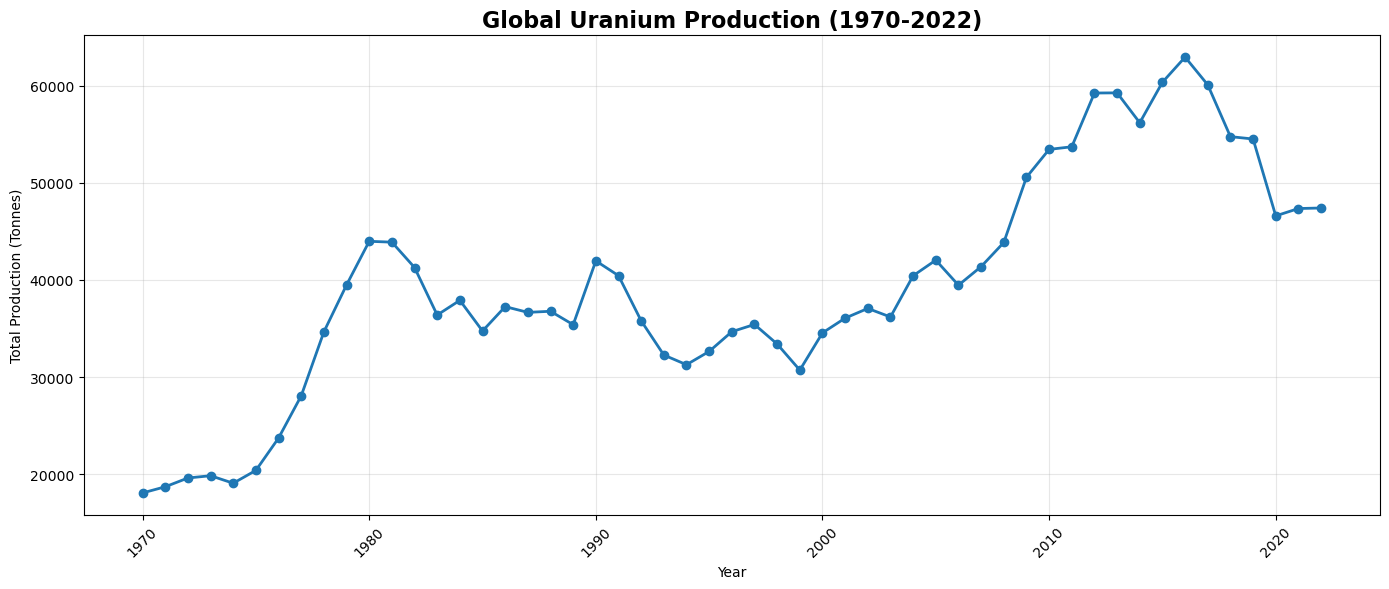

In [26]:
# 1. Global Production Trend Over Time (The Big Picture)

# Convertingng Year back to integer for this plot to get a proper time series
uranium_df.loc[:,'Year_int'] = uranium_df['Year'].astype(int)
global_trend = uranium_df.groupby('Year_int')['Production'].sum()

plt.figure(figsize=(14, 6))
plt.plot(global_trend.index, global_trend.values, marker='o', linewidth=2)
plt.title('Global Uranium Production (1970-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Production (Tonnes)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
# 1. The Plot: "Global Uranium Production"

# What to look for in this chart (The Story it tells):

# The Cold War Peak (Late 1970s - Early 1980s): You should see a massive spike here. This was driven by nuclear arms proliferation and a major push for nuclear energy.

# The Post-Cold War Collapse (Post-1989): After the collapse of the Soviet Union and the end of the arms race, demand plummeted. Combined with incidents like Chernobyl (1986), public trust fell, and production crashed. This is likely the steep decline you see.

# The Renaissance (Mid-2000s - 2010s): Concerns about climate change and energy security led to a "nuclear renaissance." Production rose again to meet planned new reactor constructions. You should see a clear upward trend here.

# The Fukushima Dip (2011): The Fukushima Daiichi nuclear disaster in 2011 led many countries (e.g., Germany, Japan) to reconsider nuclear power. This likely caused a stall or dip in the production growth around 2011-2012.

# The Modern Era (2015-Present): The market became dominated by a few key players (like Kazakhstan). The trend here shows if production has continued to grow or plateaued.

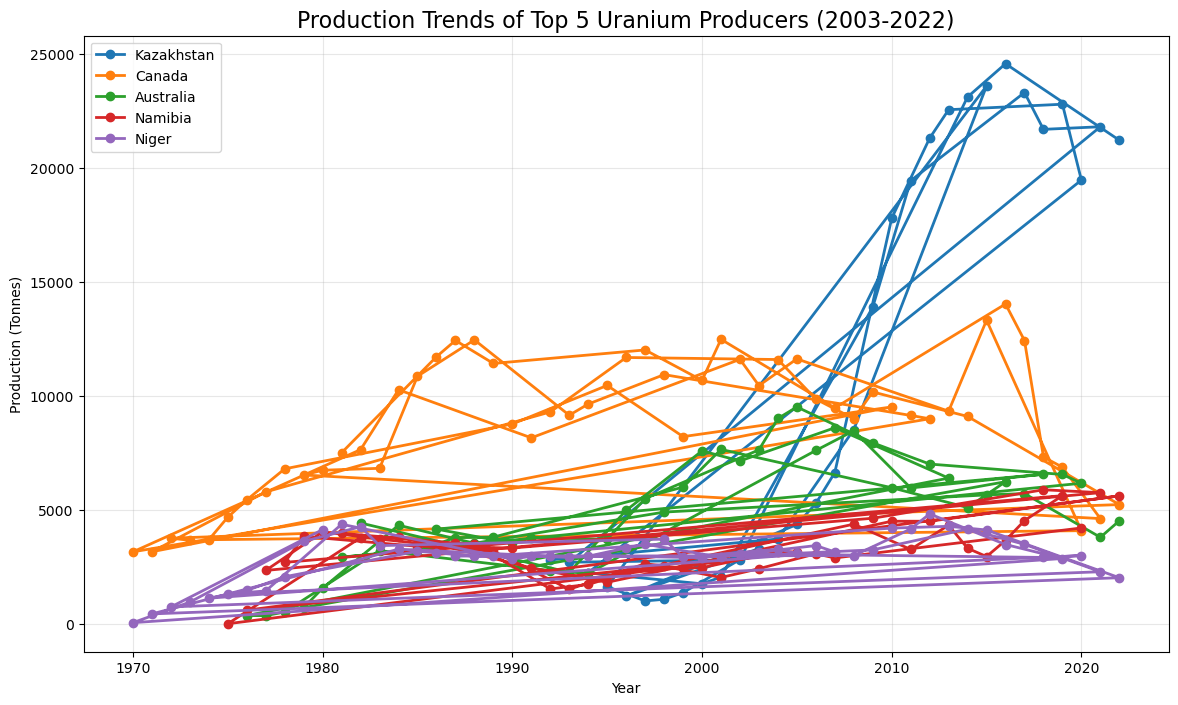

In [28]:
# 2. The Rise of Kazakhstan (The "Why" for the Modern Era)

# Filter for top 5 countries in the last 20 years
top_countries = uranium_df[uranium_df['Year_int'] > 2002].groupby('Country')['Production'].sum().nlargest(5).index.tolist()
uranium_top_df = uranium_df[uranium_df['Country'].isin(top_countries)]

# Create a line plot for each top country
plt.figure(figsize=(14, 8))
for country in top_countries:
    country_data = uranium_top_df[uranium_top_df['Country'] == country]
    plt.plot(country_data['Year_int'], country_data['Production'], marker='o', label=country, linewidth=2)

plt.title('Production Trends of Top 5 Uranium Producers (2003-2022)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Production (Tonnes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

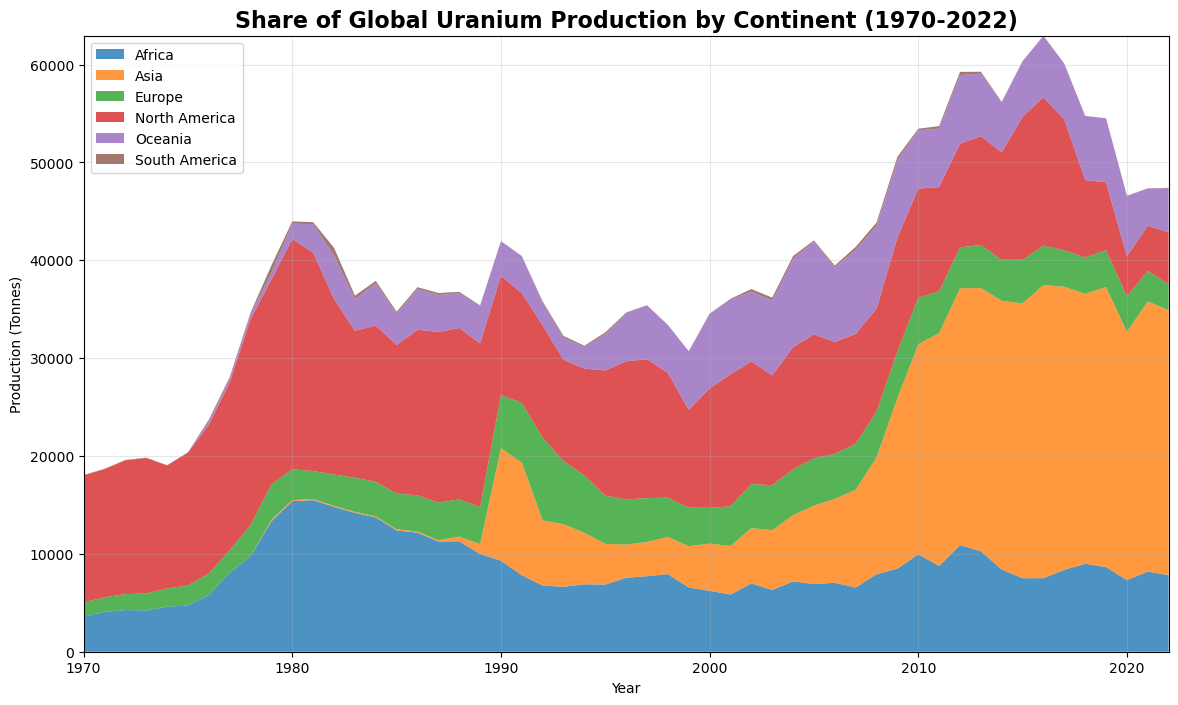

In [29]:
# 3. Analyze by Continent Over Time (Use your new feature!)

# Create a pivot table to get production for each continent for each year
continent_pivot = uranium_df.pivot_table(
    index='Year_int', 
    columns='Continent', 
    values='Production', 
    aggfunc='sum'
).fillna(0) # Fill NaN years with 0 for a continent

# Create the stacked area chart
plt.figure(figsize=(14, 8))
plt.stackplot(continent_pivot.index, continent_pivot.values.T, 
              labels=continent_pivot.columns, 
              alpha=0.8) # alpha makes it a bit see-through

plt.title('Share of Global Uranium Production by Continent (1970-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Production (Tonnes)')
plt.legend(loc='upper left')
plt.margins(0, 0) # Removes the awkward margin at the start and end
plt.grid(True, alpha=0.3)
plt.show()

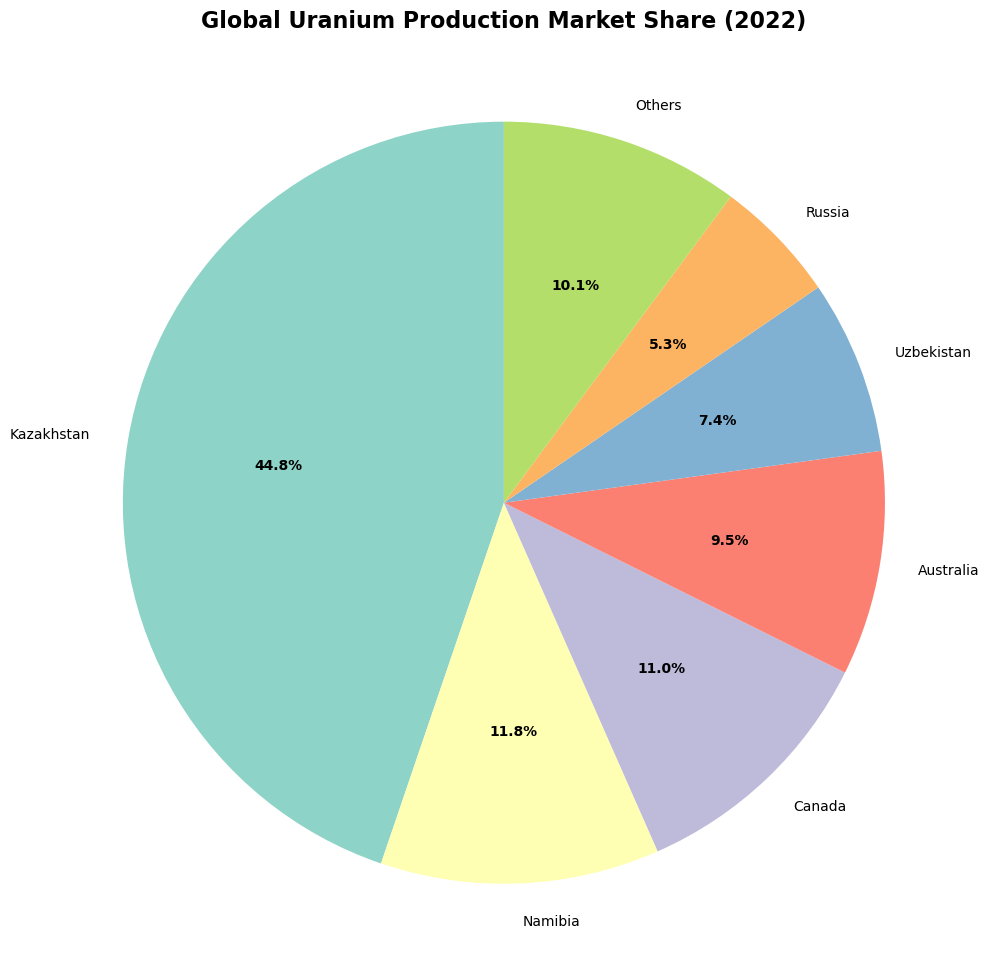

Exact Production Figures for 2022 (Tonnes):
Country
Kazakhstan        21227
Namibia            5613
Canada             5231
Australia          4519
Uzbekistan         3500
Russia             2508
Niger              2020
China              1700
India               600
South Africa        188
Ukraine             100
USA                  75
Pakistan             45
Brazil               43
Czech Republic       21
Iran                 20
Germany               0
Name: Production, dtype: int64


In [30]:
# 4. Code to create a pie chart showing the market share of the top uranium-producing countries in 2022.

# Filter data for the year 2022
production_2022 = uranium_df[uranium_df['Year_int'] == 2022]

# Group by country and sum production for 2022
market_share_2022 = production_2022.groupby('Country')['Production'].sum().sort_values(ascending=False)

# It's often useful to group very small producers into an "Others" category for a cleaner chart
# Let's keep the top N countries and group the rest
top_n = 6  # Let's show the top 6 producers
top_producers = market_share_2022.head(top_n)
others_production = market_share_2022[top_n:].sum()

# Create a new series for the pie chart, including the "Others" category
if others_production > 0:
    # Use pd.concat instead of .append()
    pie_data = pd.concat([top_producers, pd.Series({'Others': others_production})])
else:
    pie_data = top_producers

# Create the pie chart
plt.figure(figsize=(10, 10))
colors = plt.get_cmap('Set3').colors  # Use a colormap with distinct colors
wedges, texts, autotexts = plt.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
                                   startangle=90, colors=colors)

# Improve the autopct labels to be more readable
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.title('Global Uranium Production Market Share (2022)', fontsize=16, fontweight='bold')
plt.axis('equal')  # Ensures the pie is drawn as a circle
plt.tight_layout()
plt.show()

# Print out the exact numbers for reference
print("Exact Production Figures for 2022 (Tonnes):")
print(market_share_2022)

In [31]:
market_share_2022

Country
Kazakhstan        21227
Namibia            5613
Canada             5231
Australia          4519
Uzbekistan         3500
Russia             2508
Niger              2020
China              1700
India               600
South Africa        188
Ukraine             100
USA                  75
Pakistan             45
Brazil               43
Czech Republic       21
Iran                 20
Germany               0
Name: Production, dtype: int64

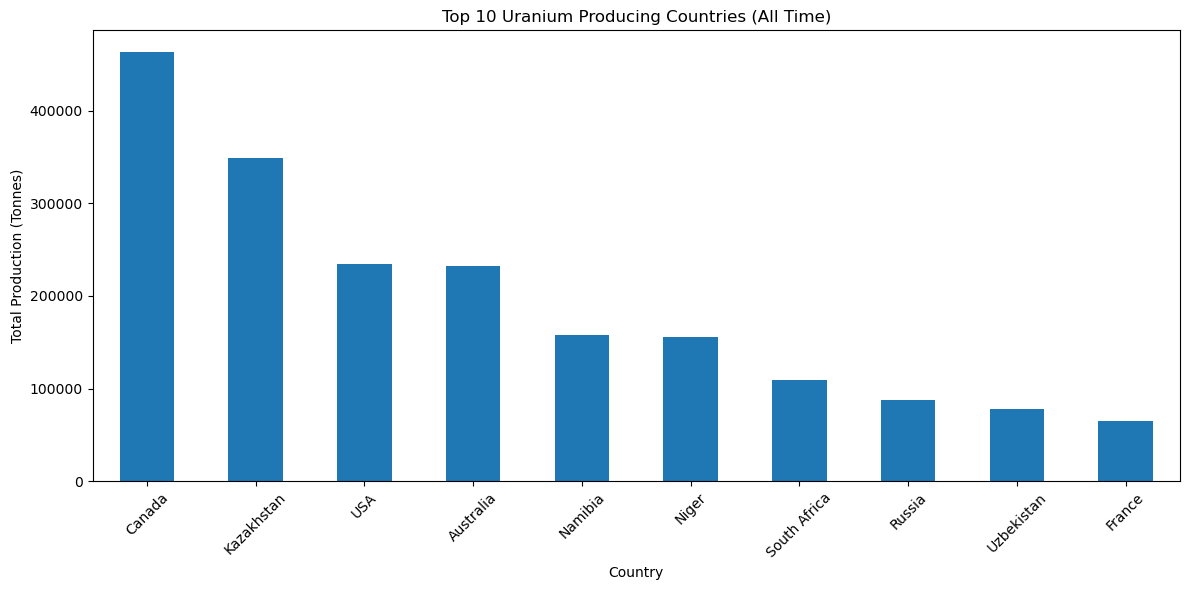

In [32]:
# Q5: Total production for each country
country_totals = uranium_df.groupby('Country')['Production'].sum().sort_values(ascending=False)

# Plot a bar chart for the top 10
plt.figure(figsize=(12, 6))
country_totals.head(10).plot(kind='bar')
plt.title('Top 10 Uranium Producing Countries (All Time)')
plt.ylabel('Total Production (Tonnes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

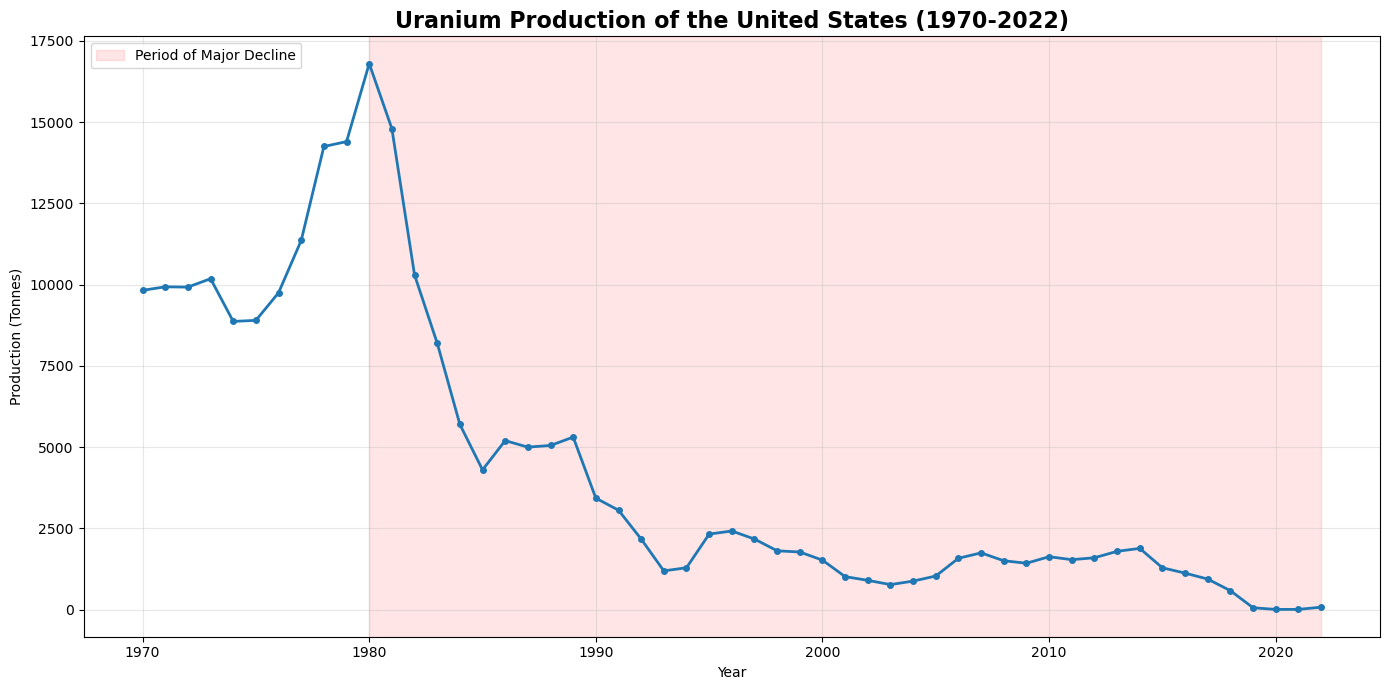

Key USA Production Statistics:
- Peak Production: 16,800 tonnes (1980)
- Production in 2022: 75 tonnes
- Percentage Decline: 99.6%


In [33]:
# Q6. Country Deep Dive: USA (The Fall of a Giant)

# Filter the data for the USA
usa_data = uranium_df[uranium_df['Country'] == 'USA'].sort_values('Year_int')

# Create the plot
plt.figure(figsize=(14, 7))
plt.plot(usa_data['Year_int'], usa_data['Production'], marker='o', linewidth=2, color='#1f77b4', markersize=4)
plt.title('Uranium Production of the United States (1970-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Production (Tonnes)')
plt.grid(True, alpha=0.3)

# (Optional) Add a shaded area to highlight the period of decline
peak_year = usa_data.loc[usa_data['Production'].idxmax(), 'Year_int'] # Find the year of peak production
plt.axvspan(peak_year, 2022, color='red', alpha=0.1, label='Period of Major Decline')

plt.legend()
plt.tight_layout()
plt.show()

# Print some key statistics for context
peak_production = usa_data['Production'].max()
latest_production = usa_data[usa_data['Year_int'] == 2022]['Production'].values
latest_production = latest_production[0] if len(latest_production) > 0 else 0

print(f"Key USA Production Statistics:")
print(f"- Peak Production: {peak_production:,} tonnes ({peak_year})")
print(f"- Production in 2022: {latest_production:,} tonnes")
print(f"- Percentage Decline: {((peak_production - latest_production) / peak_production * 100):.1f}%")

Original production_df shape: (53, 5)
Production_df columns: ['Country', 'Continent', 'Year', 'Production', 'Year_int']
Production_df years range: 1970 to 2022
Production_df Year dtype: string
Production_df sample:
   Country      Continent  Year  Production  Year_int
41     USA  North America  1983        8200      1983
42     USA  North America  1984        5700      1984
43     USA  North America  1985        4300      1985
88     USA  North America  1998        1810      1998
89     USA  North America  2000        1522      2000

Price_df years range: 1990 to 2025
Price_df Year dtype: int32
Annual avg price years range: 1990 to 2025
Annual avg price Year dtype: int32

Merged_df shape: (33, 6)
Merged_df sample:
  Country      Continent  Year  Production  Year_int  Annual_Avg_Price_($/lb)
0     USA  North America  1998        1810      1998                10.387153
1     USA  North America  2000        1522      2000                 8.284597
2     USA  North America  2010        1628

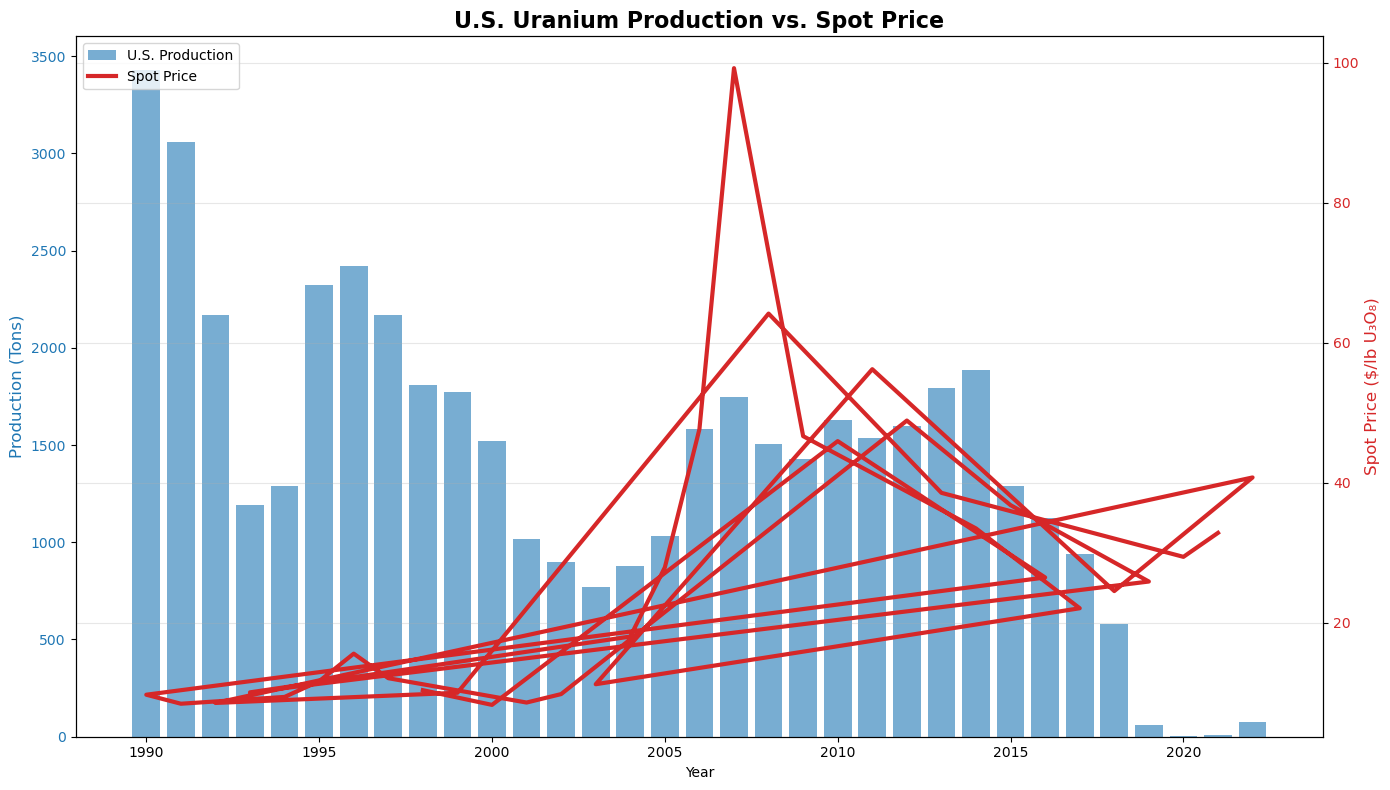

In [34]:
# Q6b

# 1. Load your datasets
production_df = uranium_df[uranium_df['Country'] == 'USA'].copy()
price_df = pd.read_csv('Desktop/Microsoft Office/Individual projects/CSV DATABASES/Metal Production/Uranium_price.csv')

print("Original production_df shape:", production_df.shape)
print("Production_df columns:", production_df.columns.tolist())
print("Production_df years range:", production_df['Year'].min(), "to", production_df['Year'].max())
print("Production_df Year dtype:", production_df['Year'].dtype)  # Check the data type
print("Production_df sample:")
print(production_df.head())

# 2. Convert date columns and extract year as INTEGER
price_df['observation_date'] = pd.to_datetime(price_df['observation_date'])
price_df['Year'] = price_df['observation_date'].dt.year

print("\nPrice_df years range:", price_df['Year'].min(), "to", price_df['Year'].max())
print("Price_df Year dtype:", price_df['Year'].dtype)  # Check the data type

# 3. Calculate the annual average price
annual_avg_price = price_df.groupby('Year')['PURANUSDM'].mean().reset_index()
annual_avg_price.rename(columns={'PURANUSDM': 'Annual_Avg_Price_($/lb)'}, inplace=True)

print("Annual avg price years range:", annual_avg_price['Year'].min(), "to", annual_avg_price['Year'].max())
print("Annual avg price Year dtype:", annual_avg_price['Year'].dtype)  # Check the data type

# FIX: Ensure both Year columns are integers for merging
production_df['Year'] = production_df['Year'].astype(int)  # Convert string to integer
annual_avg_price['Year'] = annual_avg_price['Year'].astype(int)  # Ensure it's integer

# 4. Merge the dataframes
merged_df = pd.merge(production_df, annual_avg_price, on='Year', how='inner')

print("\nMerged_df shape:", merged_df.shape)
print("Merged_df sample:")
print(merged_df.head())

# Only proceed with plotting if we have data
if len(merged_df) > 0:
    # 5. Now create the overlay visualization
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Create the first axis for PRODUCTION (bars)
    color = 'tab:blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Production (Tons)', color=color, fontsize=12)

    # Use the correct production column name
    production_column = 'Production'  # Make sure this matches exactly!
    bars = ax1.bar(merged_df['Year'], merged_df[production_column], color=color, alpha=0.6, label='U.S. Production')
    ax1.tick_params(axis='y', labelcolor=color)

    # Create a second y-axis for the PRICE (line)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Spot Price ($/lb U₃O₈)', color=color, fontsize=12)
    line = ax2.plot(merged_df['Year'], merged_df['Annual_Avg_Price_($/lb)'], color=color, linewidth=3, label='Spot Price')
    ax2.tick_params(axis='y', labelcolor=color)

    # Add titles, grid, and legend
    plt.title('U.S. Uranium Production vs. Spot Price', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    fig.tight_layout()
    plt.show()
else:
    print("ERROR: No data after merge! Check the following:")
    print("1. Production years:", production_df['Year'].unique()[:10])
    print("2. Price years:", annual_avg_price['Year'].unique()[:10])
    print("3. Common years:", set(production_df['Year']).intersection(set(annual_avg_price['Year'])))